# Member 4: Comprehensive Model Evaluation
## Bank Telemarketing Prediction — Applied Predictive Analytics Project

**Objective:** Evaluate all baseline (Member 2) and advanced (Member 3) models across 4 scenarios, with and without SMOTE. Includes threshold optimisation and lift analysis.

| Member | Responsibility | Models |
|--------|---------------|--------|
| Member 2 | Baseline models | Logistic Regression, Lasso (L1), Ridge (L2), Decision Tree |
| Member 3 | Advanced models | KNN, Random Forest, SVM (RBF), XGBoost |
| Member 4 | Evaluation | All metrics, visualisations, threshold optimisation, lift |

> **Note on SVM:** SVM (RBF) results are loaded from Member 3's pre-computed CSV files. Running SVM from scratch on this dataset (~45k rows) is extremely slow; all other models are retrained here to reproduce results exactly.


## 1. Imports & Setup

In [1]:
# ============================================================
# 1. IMPORTS & SETUP
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
TEAL   = '#01696F'
RUST   = '#A84B2F'
NAVY   = '#1A2B3C'
GOLD   = '#D19900'
PURPLE = '#7A39BB'
COLORS = [TEAL, RUST, NAVY, GOLD, PURPLE, '#437A22', '#944454', '#848456']

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 2. Data Loading & Preprocessing

In [2]:
# ============================================================
# 2. LOAD DATA — Strictly 16 original features
# ============================================================

df = pd.read_csv('bankclean.csv')

ORIGINAL_FEATURES = [
    'age', 'job', 'marital', 'education', 'default',
    'balance', 'housing', 'loan', 'contact', 'month',
    'duration', 'campaign', 'pdays', 'previous', 'poutcome'
]

# Ensure we only use original 15 input features (+ target = 16 columns total)
df_model = df[ORIGINAL_FEATURES + ['y']].copy()

y = (df_model['y'] == 'yes').astype(int)
X = df_model.drop('y', axis=1)

print(f"Dataset shape: {df_model.shape}")
print(f"Features used: {X.columns.tolist()}")
print(f"Target distribution: yes={y.sum()} ({y.mean()*100:.1f}%), no={len(y)-y.sum()} ({(1-y.mean())*100:.1f}%)")

# ── Train/Test Split (identical to Member 2 & 3) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean()*100:.1f}%  |  Test positive rate: {y_test.mean()*100:.1f}%")


Dataset shape: (45211, 16)
Features used: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']
Target distribution: yes=5289 (11.7%), no=39922 (88.3%)

Train: (36168, 15)  |  Test: (9043, 15)
Train positive rate: 11.7%  |  Test positive rate: 11.7%


## 3. Scenario Definitions

In [3]:
# ============================================================
# 3. FOUR SCENARIOS (identical to Member 2 & 3)
# ============================================================

# S1: All features including duration
X_train_S1, X_test_S1 = X_train.copy(), X_test.copy()

# S2: No duration (realistic — duration not known before call)
X_train_S2 = X_train.drop(columns=['duration'])
X_test_S2  = X_test.drop(columns=['duration'])

# S3: Demographics only
DEMO_COLS = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
X_train_S3 = X_train[DEMO_COLS]
X_test_S3  = X_test[DEMO_COLS]

# S4: Previous campaign only
PREV_COLS = ['pdays', 'previous', 'poutcome']
X_train_S4 = X_train[PREV_COLS]
X_test_S4  = X_test[PREV_COLS]

SCENARIOS = {
    'S1_All_WithDuration':      (X_train_S1, X_test_S1),
    'S2_Realistic_NoDuration':  (X_train_S2, X_test_S2),
    'S3_DemographicsOnly':      (X_train_S3, X_test_S3),
    'S4_PreviousOnly':          (X_train_S4, X_test_S4),
}
SCENARIO_LABELS = {
    'S1_All_WithDuration':     'S1: All Features (w/ Duration)',
    'S2_Realistic_NoDuration': 'S2: Realistic (No Duration)',
    'S3_DemographicsOnly':     'S3: Demographics Only',
    'S4_PreviousOnly':         'S4: Previous Campaign Only',
}

print("Scenario feature counts:")
for name, (Xtr, _) in SCENARIOS.items():
    print(f"  {name}: {Xtr.shape[1]} features")


Scenario feature counts:
  S1_All_WithDuration: 15 features
  S2_Realistic_NoDuration: 14 features
  S3_DemographicsOnly: 8 features
  S4_PreviousOnly: 3 features


## 4. Preprocessing & Evaluation Helpers

In [4]:
# ============================================================
# 4. SHARED HELPER FUNCTIONS
# ============================================================

def create_preprocessor(X):
    """
    ColumnTransformer: StandardScaler for numeric, OHE for categorical.
    Matches Member 2 & 3 pipeline exactly.
    """
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])


def train_evaluate(X_train, X_test, y_train, y_test,
                   model, model_name, scenario_name, use_smote=False):
    """
    Build pipeline, fit, predict, return metrics dict + fitted pipeline.
    Mirrors the evaluate_model() function used by Member 2 & 3.
    """
    preprocessor = create_preprocessor(X_train)

    if use_smote:
        pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
    else:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    return {
        'Model':     model_name,
        'Scenario':  scenario_name,
        'SMOTE':     'Yes' if use_smote else 'No',
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1':        round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba),  4),
    }, pipeline, y_proba


print("✅ Helper functions defined.")


✅ Helper functions defined.


## 5. Baseline Models (Member 2)
Models: **Logistic Regression**, **Lasso (L1)**, **Ridge (L2)**, **Decision Tree**  
Across all 4 scenarios × 2 SMOTE settings = **32 runs**


In [5]:
# ============================================================
# 5. BASELINE MODELS — Reproducing Member 2 results exactly
# ============================================================

BASELINE_MODEL_NAMES = ['Logistic Regression', 'Lasso (L1)', 'Ridge (L2)', 'Decision Tree']

def make_baseline_model(name):
    # Instantiate a fresh baseline model to avoid state sharing.
    if name == 'Logistic Regression':
        return LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Lasso (L1)':
        return LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
    elif name == 'Ridge (L2)':
        return LogisticRegression(penalty='l2', max_iter=1000, random_state=42)
    elif name == 'Decision Tree':
        return DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=50)

baseline_results  = []
baseline_pipelines = {}   # (model_name, scenario, smote) -> pipeline
baseline_probas    = {}   # (model_name, scenario, smote) -> y_proba

for scenario_name, (X_tr, X_te) in SCENARIOS.items():
    print(f"[{scenario_name}]")
    for model_name in BASELINE_MODEL_NAMES:
        model_obj = make_baseline_model(model_name)
        for use_smote in [False, True]:
            tag = 'SMOTE' if use_smote else 'no SMOTE'
            res, pipe, proba = train_evaluate(
                X_tr, X_te, y_train, y_test,
                model_obj, model_name, scenario_name, use_smote
            )
            baseline_results.append(res)
            baseline_pipelines[(model_name, scenario_name, use_smote)] = pipe
            baseline_probas[(model_name, scenario_name, use_smote)]    = proba
            print(f"  {model_name:25s} | {tag:9s} | "
                  f"AUC={res['ROC-AUC']:.4f}  Recall={res['Recall']:.4f}")

baseline_df = pd.DataFrame(baseline_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
baseline_df.insert(0, 'Rank', baseline_df.index + 1)

print(f"\n✅ Baseline complete — {len(baseline_df)} runs.")


[S1_All_WithDuration]


  Logistic Regression       | no SMOTE  | AUC=0.9058  Recall=0.3478


  Logistic Regression       | SMOTE     | AUC=0.9066  Recall=0.8072


  Lasso (L1)                | no SMOTE  | AUC=0.9058  Recall=0.3488


  Lasso (L1)                | SMOTE     | AUC=0.9066  Recall=0.8072


...

  Decision Tree             | SMOTE     | AUC=0.6670  Recall=0.5643
[S4_PreviousOnly]
  Logistic Regression       | no SMOTE  | AUC=0.6223  Recall=0.1881


  Logistic Regression       | SMOTE     | AUC=0.6220  Recall=0.3422


  Lasso (L1)                | no SMOTE  | AUC=0.6223  Recall=0.1881


  Lasso (L1)                | SMOTE     | AUC=0.6220  Recall=0.3412
  Ridge (L2)                | no SMOTE  | AUC=0.6223  Recall=0.1881


  Ridge (L2)                | SMOTE     | AUC=0.6220  Recall=0.3422
  Decision Tree             | no SMOTE  | AUC=0.6063  Recall=0.1569
  Decision Tree             | SMOTE     | AUC=0.6018  Recall=0.2599

✅ Baseline complete — 32 runs.


In [6]:
# ── Display baseline results table ────────────────────────────────
print("=" * 90)
print("BASELINE MODEL RESULTS (sorted by ROC-AUC)")
print("=" * 90)
display(baseline_df.style
    .background_gradient(subset=['ROC-AUC', 'F1'], cmap='YlOrBr')
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1','ROC-AUC']})
    .set_caption("Member 2 — Baseline Models: All Scenarios × SMOTE"))


BASELINE MODEL RESULTS (sorted by ROC-AUC)


,Rank,Model,Scenario,SMOTE,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,Logistic Regression,S1_All_WithDuration,Yes,0.8458,0.4178,0.8072,0.5506,0.9066
1,2,Lasso (L1),S1_All_WithDuration,Yes,0.8455,0.4172,0.8072,0.5501,0.9066
2,3,Ridge (L2),S1_All_WithDuration,Yes,0.8458,0.4178,0.8072,0.5506,0.9066
3,4,Logistic Regression,S1_All_WithDuration,No,0.9015,0.6467,0.3478,0.4524,0.9058
4,5,Lasso (L1),S1_All_WithDuration,No,0.9016,0.6474,0.3488,0.4533,0.9058
5,6,Ridge (L2),S1_All_WithDuration,No,0.9015,0.6467,0.3478,0.4524,0.9058
6,7,Decision Tree,S1_All_WithDuration,No,0.9008,0.6075,0.4301,0.5036,0.8862
7,8,Decision Tree,S1_All_WithDuration,Yes,0.8374,0.4001,0.7798,0.5288,0.8764
8,9,Logistic Regression,S2_Realistic_NoDuration,No,0.8933,0.6609,0.1805,0.2836,0.7724
9,10,Lasso (L1),S2_Realistic_NoDuration,No,0.8935,0.6644,0.1815,0.2851,0.7724


## 6. Advanced Models (Member 3)
Models: **KNN**, **Random Forest**, **SVM (RBF)**, **XGBoost**  
Across all 4 scenarios × 2 SMOTE settings = **32 runs**

> **SVM note:** SVM (RBF) results are loaded directly from Member 3's pre-computed CSV files to avoid multi-hour runtimes. All other advanced models are retrained.


In [7]:
# ============================================================
# 6. ADVANCED MODELS — Reproducing Member 3 results
#    SVM: loaded from pre-computed CSVs
#    KNN / RF / XGBoost: retrained here
# ============================================================

# ── Load SVM results from Member 3's CSVs ─────────────────────────
SVM_FILES = {
    ('S1_All_WithDuration',     False): 'advanced_results_S1.csv',
    ('S2_Realistic_NoDuration', False): 'advanced_results_S2.csv',
    ('S3_DemographicsOnly',     False): 'advanced_results_S3.csv',
    ('S4_PreviousOnly',         False): 'advanced_results_S4.csv',
    ('S1_All_WithDuration',     True):  'advanced_smote_results_S1.csv',
    ('S2_Realistic_NoDuration', True):  'advanced_smote_results_S2.csv',
    ('S3_DemographicsOnly',     True):  'advanced_smote_results_S3.csv',
    ('S4_PreviousOnly',         True):  'advanced_smote_results_S4.csv',
}

svm_rows = []
for (scen, smote), fpath in SVM_FILES.items():
    tmp = pd.read_csv(fpath)
    row = tmp[tmp['Model'] == 'SVM (RBF)'].iloc[0].to_dict()
    svm_rows.append(row)

svm_df = pd.DataFrame(svm_rows)
print(f"Loaded {len(svm_df)} SVM rows from Member 3 CSVs.")

# ── Train non-SVM advanced models ─────────────────────────────────
def make_advanced_model(name):
    # Instantiate a fresh model object to avoid state sharing across scenarios.
    if name == 'KNN':
        return KNeighborsClassifier(n_neighbors=5)
    elif name == 'Random Forest':
        return RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    elif name == 'XGBoost':
        return XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                             random_state=42, eval_metric='logloss')

NON_SVM_NAMES = ['KNN', 'Random Forest', 'XGBoost']

advanced_results   = []
advanced_pipelines = {}
advanced_probas    = {}

for scenario_name, (X_tr, X_te) in SCENARIOS.items():
    print(f"[{scenario_name}]")
    for model_name in NON_SVM_NAMES:
        model_obj = make_advanced_model(model_name)
        for use_smote in [False, True]:
            tag = 'SMOTE' if use_smote else 'no SMOTE'
            res, pipe, proba = train_evaluate(
                X_tr, X_te, y_train, y_test,
                model_obj, model_name, scenario_name, use_smote
            )
            advanced_results.append(res)
            advanced_pipelines[(model_name, scenario_name, use_smote)] = pipe
            advanced_probas[(model_name, scenario_name, use_smote)]    = proba
            print(f"  {model_name:15s} | {tag:9s} | "
                  f"AUC={res['ROC-AUC']:.4f}  Recall={res['Recall']:.4f}")

# ── Combine with SVM ──────────────────────────────────────────────
non_svm_df    = pd.DataFrame(advanced_results)
advanced_df   = pd.concat([non_svm_df, svm_df], ignore_index=True)
advanced_df   = advanced_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
advanced_df.insert(0, 'Rank', advanced_df.index + 1)

print(f"\n✅ Advanced models complete — {len(advanced_df)} runs ({len(non_svm_df)} retrained + {len(svm_df)} SVM from CSV).")


Loaded 8 SVM rows from Member 3 CSVs.
[S1_All_WithDuration]


  KNN             | no SMOTE  | AUC=0.8257  Recall=0.3535


  KNN             | SMOTE     | AUC=0.8437  Recall=0.7363


  Random Forest   | no SMOTE  | AUC=0.9198  Recall=0.1805


  Random Forest   | SMOTE     | AUC=0.9123  Recall=0.7930


...

  KNN             | no SMOTE  | AUC=0.5873  Recall=0.1701


  KNN             | SMOTE     | AUC=0.6063  Recall=0.2420


  Random Forest   | no SMOTE  | AUC=0.6201  Recall=0.1739


  Random Forest   | SMOTE     | AUC=0.6174  Recall=0.2826
  XGBoost         | no SMOTE  | AUC=0.6199  Recall=0.1664


  XGBoost         | SMOTE     | AUC=0.6190  Recall=0.2826

✅ Advanced models complete — 32 runs (24 retrained + 8 SVM from CSV).


In [8]:
# ── Display advanced results table ────────────────────────────────
print("=" * 90)
print("ADVANCED MODEL RESULTS (sorted by ROC-AUC)")
print("=" * 90)
display(advanced_df.style
    .background_gradient(subset=['ROC-AUC', 'F1'], cmap='YlOrBr')
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1','ROC-AUC']})
    .set_caption("Member 3 — Advanced Models: All Scenarios × SMOTE"))


ADVANCED MODEL RESULTS (sorted by ROC-AUC)


,Rank,Model,Scenario,SMOTE,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,XGBoost,S1_All_WithDuration,No,0.9097,0.6644,0.4603,0.5438,0.9279
1,2,Random Forest,S1_All_WithDuration,No,0.8967,0.7403,0.1805,0.2903,0.9198
2,3,XGBoost,S1_All_WithDuration,Yes,0.8924,0.5314,0.6796,0.5964,0.9197
3,4,Random Forest,S1_All_WithDuration,Yes,0.8578,0.4402,0.7930,0.5661,0.9123
4,5,KNN,S1_All_WithDuration,Yes,0.8330,0.3876,0.7363,0.5078,0.8437
5,6,KNN,S1_All_WithDuration,No,0.8947,0.5826,0.3535,0.4400,0.8257
6,7,XGBoost,S2_Realistic_NoDuration,No,0.8965,0.6694,0.2278,0.3399,0.7940
7,8,Random Forest,S2_Realistic_NoDuration,No,0.8943,0.7090,0.1635,0.2657,0.7911
8,9,Random Forest,S2_Realistic_NoDuration,Yes,0.8420,0.3769,0.5369,0.4429,0.7797
9,10,XGBoost,S2_Realistic_NoDuration,Yes,0.8881,0.5307,0.3762,0.4403,0.7704


## 7. Combined Results — All Models

In [9]:
# ============================================================
# 7. COMBINED RESULTS TABLE
# ============================================================

all_results_df = pd.concat(
    [baseline_df.drop(columns='Rank'), advanced_df.drop(columns='Rank')],
    ignore_index=True
)
all_results_df = all_results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
all_results_df.insert(0, 'Rank', all_results_df.index + 1)

print(f"Total model runs: {len(all_results_df)}")
print(f"\nTOP 10 OVERALL (by ROC-AUC):")
display(all_results_df.head(10).style
    .background_gradient(subset=['ROC-AUC', 'F1'], cmap='YlOrBr')
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1','ROC-AUC']})
    .set_caption("All Models — Top 10 by ROC-AUC"))


Total model runs: 64

TOP 10 OVERALL (by ROC-AUC):


,Rank,Model,Scenario,SMOTE,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,XGBoost,S1_All_WithDuration,No,0.9097,0.6644,0.4603,0.5438,0.9279
1,2,Random Forest,S1_All_WithDuration,No,0.8967,0.7403,0.1805,0.2903,0.9198
2,3,XGBoost,S1_All_WithDuration,Yes,0.8924,0.5314,0.6796,0.5964,0.9197
3,4,Random Forest,S1_All_WithDuration,Yes,0.8578,0.4402,0.7930,0.5661,0.9123
4,5,Logistic Regression,S1_All_WithDuration,Yes,0.8458,0.4178,0.8072,0.5506,0.9066
5,6,Lasso (L1),S1_All_WithDuration,Yes,0.8455,0.4172,0.8072,0.5501,0.9066
6,7,Ridge (L2),S1_All_WithDuration,Yes,0.8458,0.4178,0.8072,0.5506,0.9066
7,8,Logistic Regression,S1_All_WithDuration,No,0.9015,0.6467,0.3478,0.4524,0.9058
8,9,Lasso (L1),S1_All_WithDuration,No,0.9016,0.6474,0.3488,0.4533,0.9058
9,10,Ridge (L2),S1_All_WithDuration,No,0.9015,0.6467,0.3478,0.4524,0.9058


## 8. Visualisation — ROC-AUC Comparison

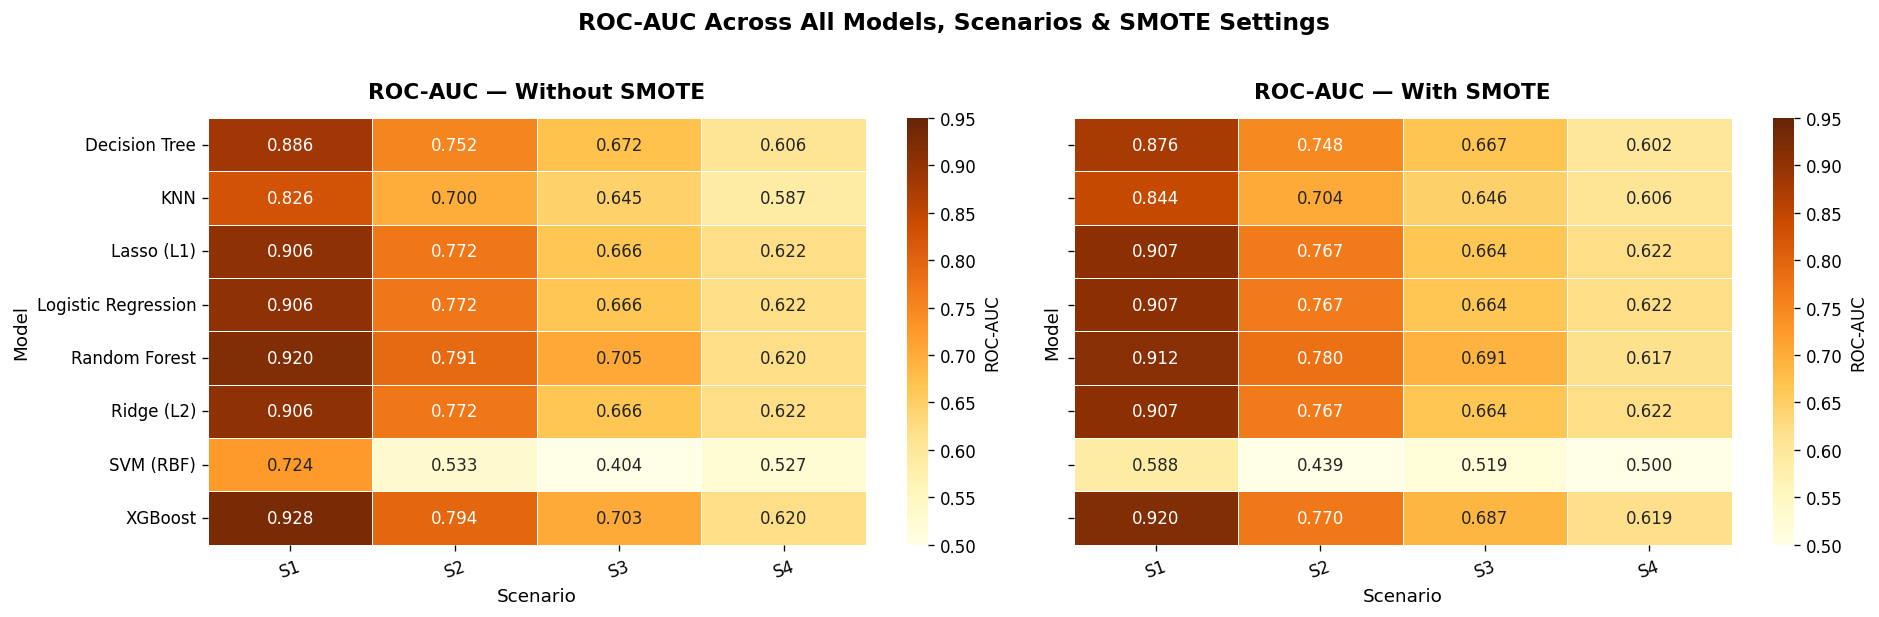

Saved: eval_roc_auc_heatmap.png


In [10]:
# ============================================================
# 8A. ROC-AUC HEATMAP — All models × scenarios × SMOTE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
titles = ['Without SMOTE', 'With SMOTE']

for ax, smote_val in zip(axes, ['No', 'Yes']):
    subset = all_results_df[all_results_df['SMOTE'] == smote_val]
    pivot  = subset.pivot_table(
        index='Model', columns='Scenario', values='ROC-AUC', aggfunc='mean'
    )
    # Rename columns for readability
    pivot.columns = [c.split('_')[0] for c in pivot.columns]

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.3f',
        cmap='YlOrBr', vmin=0.50, vmax=0.95,
        linewidths=0.5, cbar_kws={'label': 'ROC-AUC'}
    )
    ax.set_title(f'ROC-AUC — {titles[smote_val == "Yes"]}',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Scenario', fontsize=11)
    ax.set_ylabel('Model', fontsize=11)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('ROC-AUC Across All Models, Scenarios & SMOTE Settings',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_roc_auc_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_roc_auc_heatmap.png")


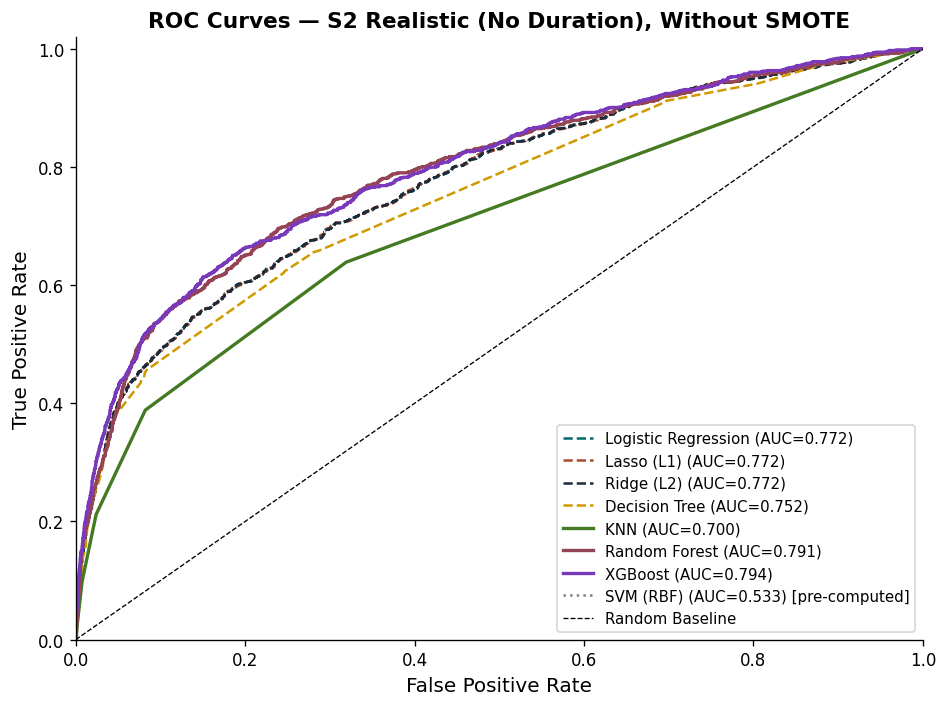

Saved: eval_roc_curves_s2.png


In [11]:
# ============================================================
# 8B. ROC CURVES — S2 (Realistic), Without SMOTE
#     Best scenario for business deployment
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Baseline models
BASELINE_COLORS = {'Logistic Regression': TEAL, 'Lasso (L1)': RUST,
                   'Ridge (L2)': NAVY, 'Decision Tree': GOLD}

for model_name, color in BASELINE_COLORS.items():
    key = (model_name, 'S2_Realistic_NoDuration', False)
    if key in baseline_probas:
        fpr, tpr, _ = roc_curve(y_test, baseline_probas[key])
        auc_val = roc_auc_score(y_test, baseline_probas[key])
        ax.plot(fpr, tpr, color=color, lw=1.5, linestyle='--',
                label=f'{model_name} (AUC={auc_val:.3f})')

# Advanced models
ADV_COLORS = {'KNN': '#437A22', 'Random Forest': '#944454', 'XGBoost': PURPLE}
for model_name, color in ADV_COLORS.items():
    key = (model_name, 'S2_Realistic_NoDuration', False)
    if key in advanced_probas:
        fpr, tpr, _ = roc_curve(y_test, advanced_probas[key])
        auc_val = roc_auc_score(y_test, advanced_probas[key])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{model_name} (AUC={auc_val:.3f})')

# SVM from CSV — AUC only (no probas available from CSV)
svm_s2_no = svm_df[(svm_df['Scenario']=='S2_Realistic_NoDuration') & (svm_df['SMOTE']=='No')]
if len(svm_s2_no):
    ax.plot([], [], color='grey', lw=1.5, linestyle=':',
            label=f"SVM (RBF) (AUC={svm_s2_no['ROC-AUC'].values[0]:.3f}) [pre-computed]")

ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — S2 Realistic (No Duration), Without SMOTE',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('eval_roc_curves_s2.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_roc_curves_s2.png")


## 8C. ROC Curves — S2, All Models (No SMOTE vs With SMOTE)

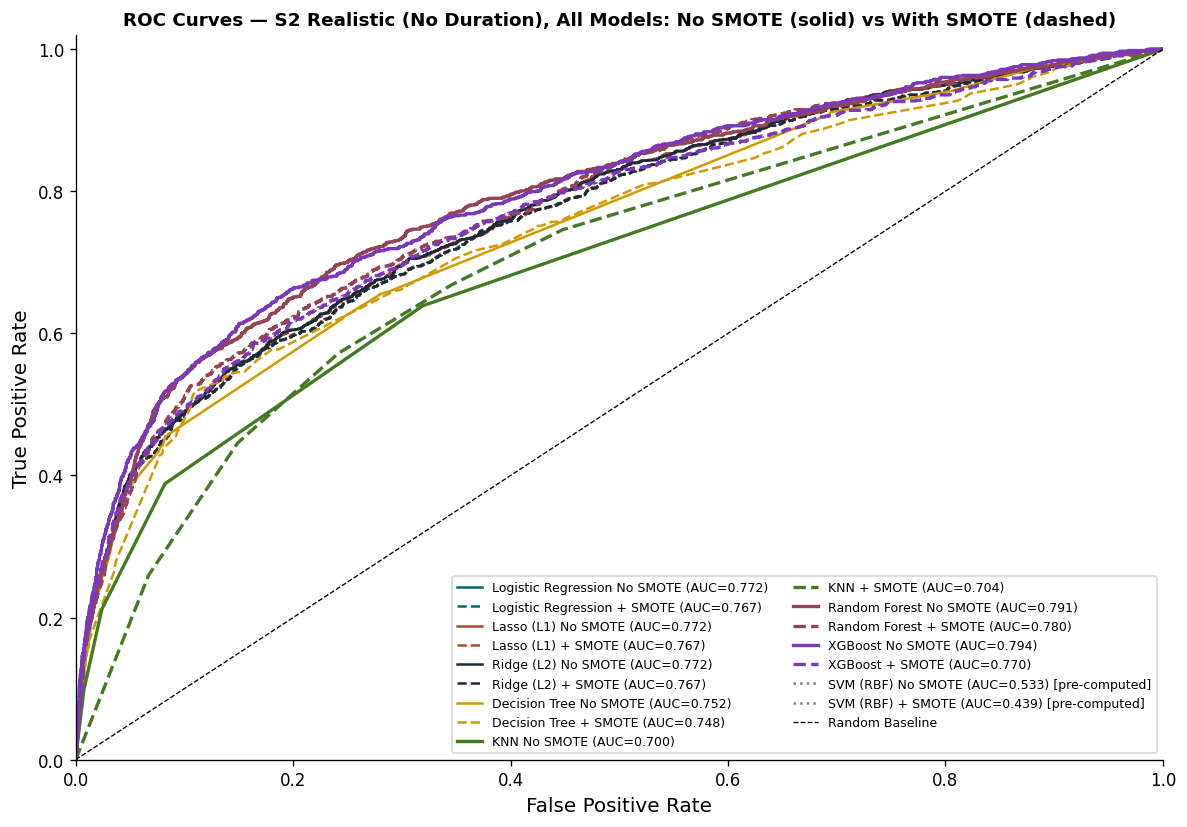

Saved: eval_roc_curves_s2_all.png


In [12]:
# ============================================================
# 8C. ROC CURVES — S2, ALL 8 MODELS + SMOTE VARIANTS
#     Solid = No SMOTE, Dashed = With SMOTE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

MODEL_COLORS = {
    'Logistic Regression': TEAL,
    'Lasso (L1)':          RUST,
    'Ridge (L2)':          NAVY,
    'Decision Tree':       GOLD,
    'KNN':                 '#437A22',
    'Random Forest':       '#944454',
    'XGBoost':             PURPLE,
}

SCEN = 'S2_Realistic_NoDuration'

# Baseline models
for model_name, color in {'Logistic Regression': TEAL, 'Lasso (L1)': RUST,
                           'Ridge (L2)': NAVY, 'Decision Tree': GOLD}.items():
    for smote_flag, ls, lbl_suffix in [(False, '-', ' No SMOTE'), (True, '--', ' + SMOTE')]:
        key = (model_name, SCEN, smote_flag)
        if key in baseline_probas:
            fpr, tpr, _ = roc_curve(y_test, baseline_probas[key])
            auc_val = roc_auc_score(y_test, baseline_probas[key])
            ax.plot(fpr, tpr, color=color, lw=1.5, linestyle=ls,
                    label=f'{model_name}{lbl_suffix} (AUC={auc_val:.3f})')

# Advanced models
for model_name, color in {'KNN': '#437A22', 'Random Forest': '#944454', 'XGBoost': PURPLE}.items():
    for smote_flag, ls, lbl_suffix in [(False, '-', ' No SMOTE'), (True, '--', ' + SMOTE')]:
        key = (model_name, SCEN, smote_flag)
        if key in advanced_probas:
            fpr, tpr, _ = roc_curve(y_test, advanced_probas[key])
            auc_val = roc_auc_score(y_test, advanced_probas[key])
            ax.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
                    label=f'{model_name}{lbl_suffix} (AUC={auc_val:.3f})')

# SVM from CSV (no probas — show as legend entry only)
for smote_val, ls, lbl_suffix in [('No', ':', ' No SMOTE'), ('Yes', ':', ' + SMOTE')]:
    row = svm_df[(svm_df['Scenario']==SCEN) & (svm_df['SMOTE']==smote_val)]
    if len(row):
        ax.plot([], [], color='grey', lw=1.5, linestyle=ls,
                label=f"SVM (RBF){lbl_suffix} (AUC={row['ROC-AUC'].values[0]:.3f}) [pre-computed]")

ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — S2 Realistic (No Duration), All Models: No SMOTE (solid) vs With SMOTE (dashed)',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('eval_roc_curves_s2_all.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_roc_curves_s2_all.png")


## 8D. Precision-Recall Curves — S2, All Models (No SMOTE | With SMOTE)

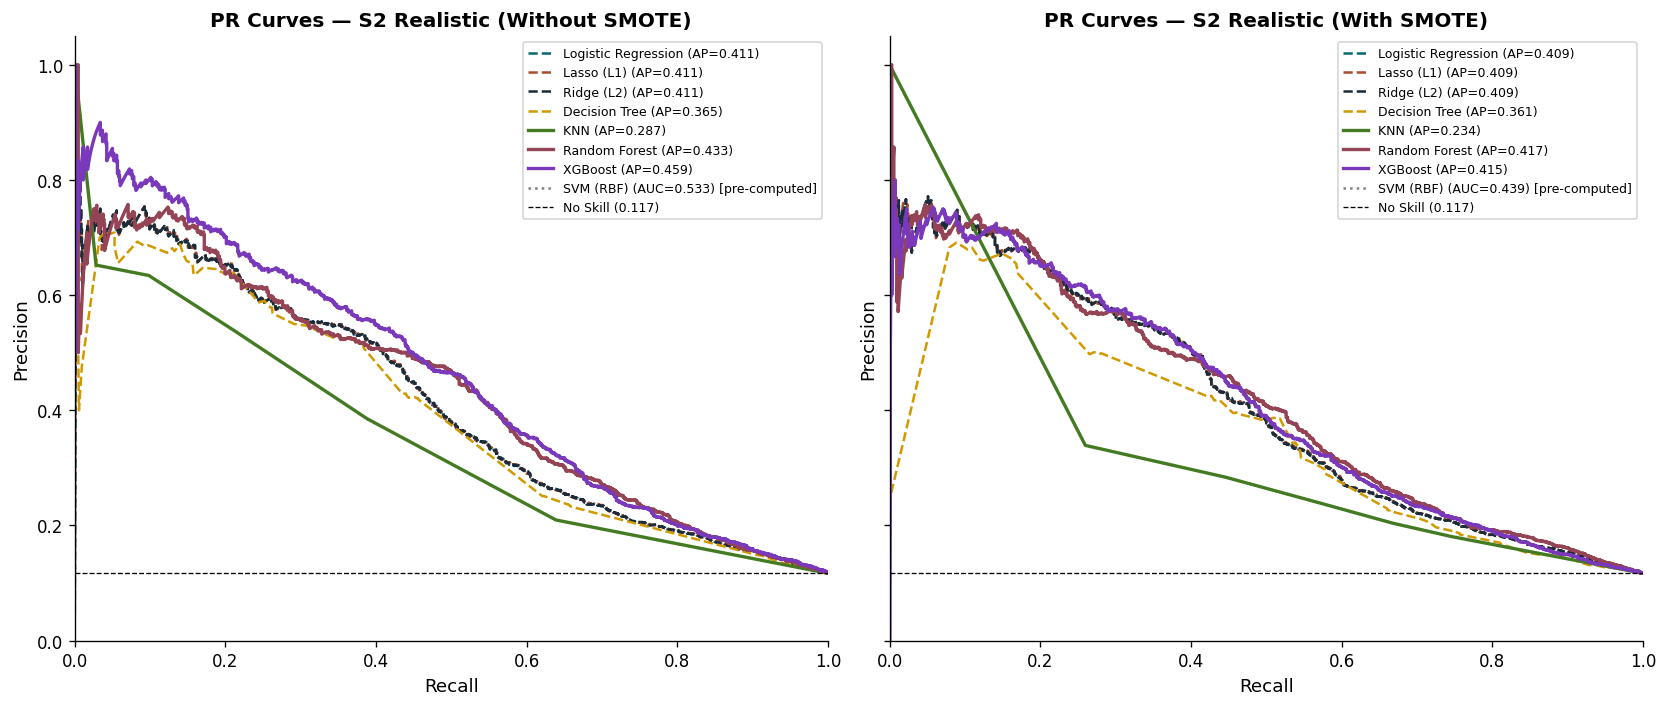

Saved: eval_pr_curves_s2_all.png


In [13]:
# ============================================================
# 8D. PR CURVES — S2, ALL MODELS
#     Left: No SMOTE | Right: With SMOTE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

SCEN = 'S2_Realistic_NoDuration'

BASELINE_PR = {'Logistic Regression': TEAL, 'Lasso (L1)': RUST,
               'Ridge (L2)': NAVY, 'Decision Tree': GOLD}
ADV_PR      = {'KNN': '#437A22', 'Random Forest': '#944454', 'XGBoost': PURPLE}

no_skill_level = y_test.mean()  # positive rate

for col_idx, (smote_flag, title_suffix) in enumerate([(False, 'Without SMOTE'), (True, 'With SMOTE')]):
    ax = axes[col_idx]

    for model_name, color in BASELINE_PR.items():
        key = (model_name, SCEN, smote_flag)
        if key in baseline_probas:
            prec, rec, _ = precision_recall_curve(y_test, baseline_probas[key])
            ap = average_precision_score(y_test, baseline_probas[key])
            ax.plot(rec, prec, color=color, lw=1.5, linestyle='--',
                    label=f'{model_name} (AP={ap:.3f})')

    for model_name, color in ADV_PR.items():
        key = (model_name, SCEN, smote_flag)
        if key in advanced_probas:
            prec, rec, _ = precision_recall_curve(y_test, advanced_probas[key])
            ap = average_precision_score(y_test, advanced_probas[key])
            ax.plot(rec, prec, color=color, lw=2,
                    label=f'{model_name} (AP={ap:.3f})')

    # SVM from CSV — show AUC label only (no probas)
    smote_val = 'Yes' if smote_flag else 'No'
    row = svm_df[(svm_df['Scenario']==SCEN) & (svm_df['SMOTE']==smote_val)]
    if len(row):
        ax.plot([], [], color='grey', lw=1.5, linestyle=':',
                label=f"SVM (RBF) (AUC={row['ROC-AUC'].values[0]:.3f}) [pre-computed]")

    ax.axhline(y=no_skill_level, color='k', linestyle='--', lw=0.8, label=f'No Skill ({no_skill_level:.3f})')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'PR Curves — S2 Realistic ({title_suffix})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7.5)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('eval_pr_curves_s2_all.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_pr_curves_s2_all.png")


## 9. Confusion Matrices — S2, Key Models

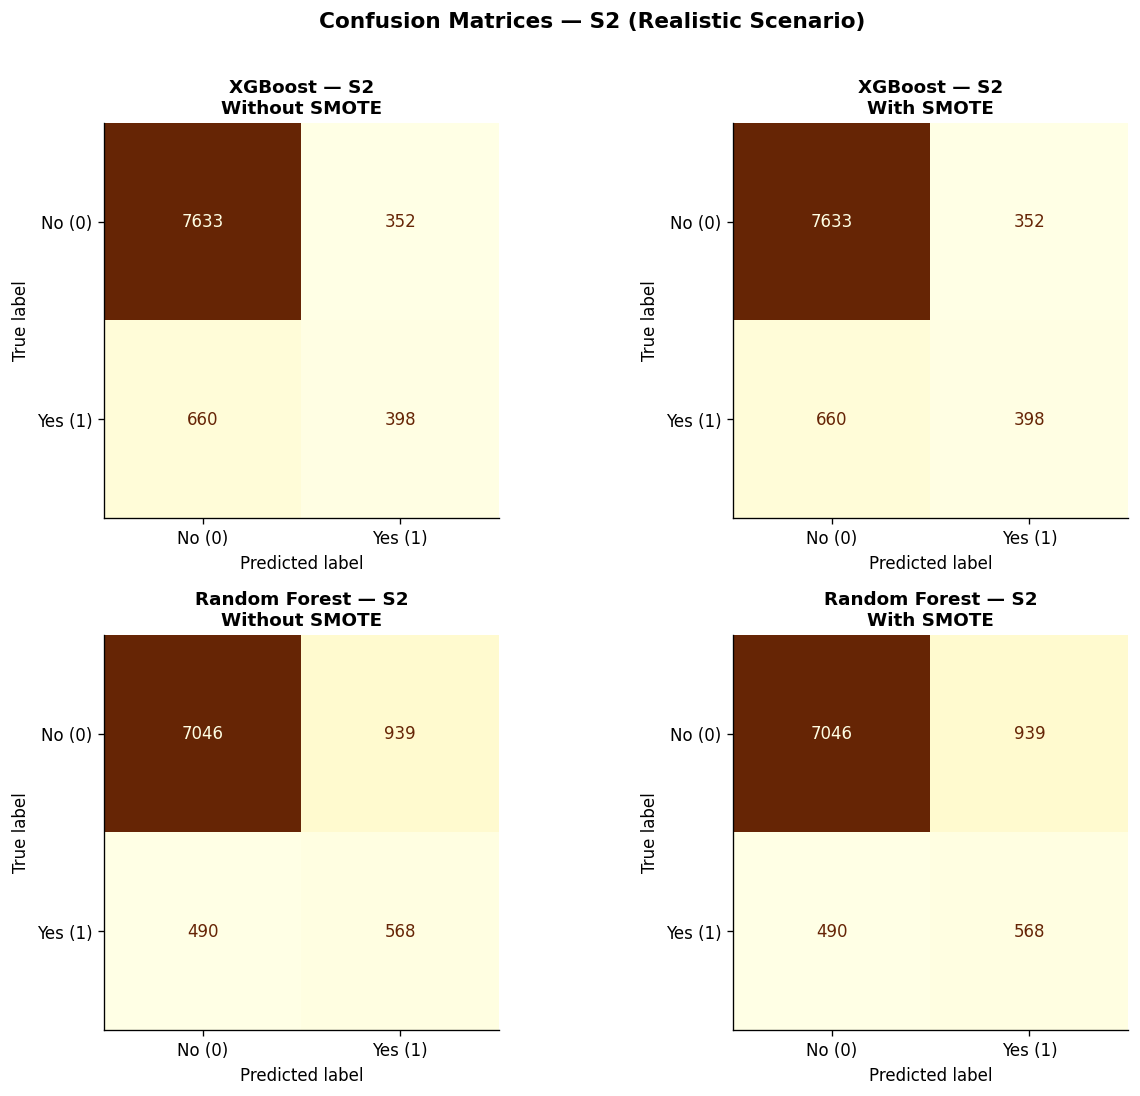

Saved: eval_confusion_matrices.png


In [14]:
# ============================================================
# 9. CONFUSION MATRICES
#    Best models in S2: XGBoost (no SMOTE) & RF (with SMOTE)
# ============================================================

CONF_TARGETS = [
    ('XGBoost',       'S2_Realistic_NoDuration', False, advanced_pipelines),
    ('XGBoost',       'S2_Realistic_NoDuration', True,  advanced_pipelines),
    ('Random Forest', 'S2_Realistic_NoDuration', False, advanced_pipelines),
    ('Random Forest', 'S2_Realistic_NoDuration', True,  advanced_pipelines),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, (mname, scen, smote, pipelines) in enumerate(CONF_TARGETS):
    key = (mname, scen, smote)
    ax  = axes[idx]
    if key in pipelines:
        X_te = SCENARIOS[scen][1]
        y_pred = pipelines[key].predict(X_te)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['No (0)', 'Yes (1)'])
        disp.plot(ax=ax, colorbar=False,
                  im_kw={'cmap': 'YlOrBr'})
        smote_label = 'With SMOTE' if smote else 'Without SMOTE'
        ax.set_title(f'{mname} — S2\n{smote_label}',
                     fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — S2 (Realistic Scenario)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eval_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_confusion_matrices.png")


## 10. SMOTE Impact Analysis

SMOTE Impact on S2 (Realistic Scenario):


F1         Precision         ROC-AUC          Recall  \
SMOTE                    No     Yes        No     Yes      No     Yes      No   
Model                                                                           
Decision Tree        0.3117  0.4263    0.6393  0.3956  0.7518  0.7478  0.2060   
KNN                  0.3039  0.3370    0.5385  0.2388  0.7000  0.7035  0.2117   
Lasso (L1)           0.2851  0.3669    0.6644  0.2591  0.7724  0.7670  0.1815   
Logistic Regression  0.2836  0.3680    0.6609  0.2597  0.7724  0.7669  0.1805   
Random Forest        0.2657  0.4429    0.7090  0.3769  0.7911  0.7797  0.1635   
Ridge (L2)           0.2836  0.3680    0.6609  0.2597  0.7724  0.7669  0.1805   
SVM (RBF)            0.1924  0.1882    0.1280  0.1072  0.5330  0.4387  0.3875   
XGBoost              0.3399  0.4403    0.6694  0.5307  0.7940  0.7704  0.2278   

                             
SMOTE                   Yes  
Model                        
Decision Tree        0.4622  
KNN                  0.5718  
Lasso (L1)           0.6285  
Logistic Regression  0.6314  
Random Forest        0.5369  
Ridge (L2)           0.6314  
SVM (RBF)            0.7684  
XGBoost              0.3762

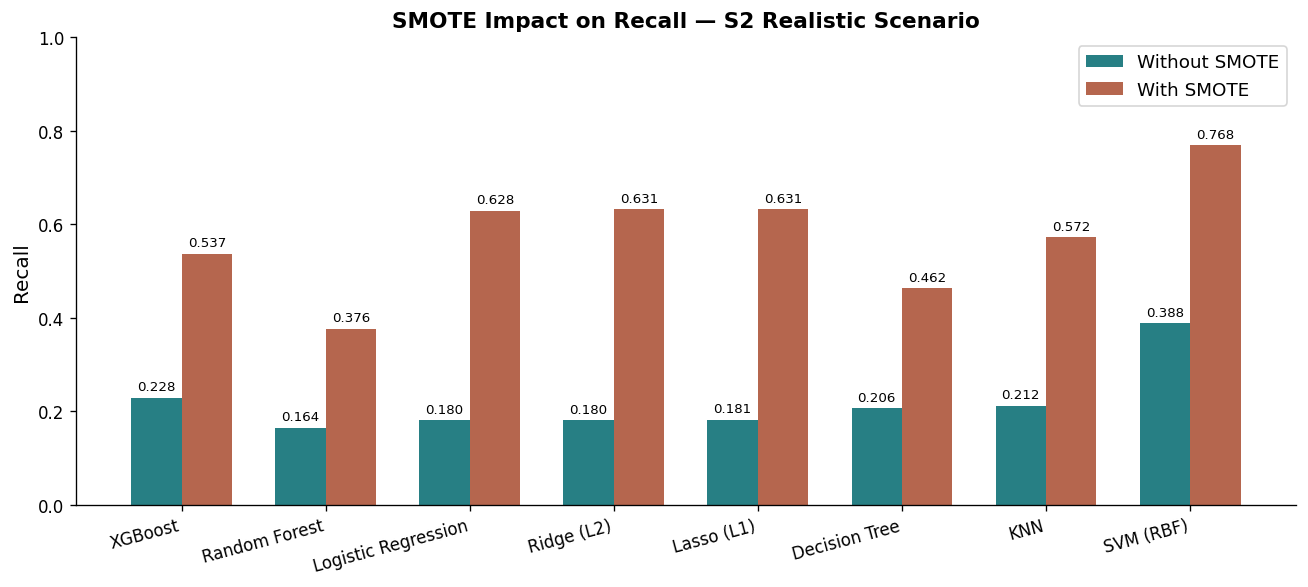

Saved: eval_smote_impact.png


In [15]:
# ============================================================
# 10. SMOTE IMPACT ON RECALL & PRECISION — S2
# ============================================================

s2_all = all_results_df[all_results_df['Scenario'] == 'S2_Realistic_NoDuration'].copy()

# Remove SVM from paired comparison (no retrained SMOTE probas)
smote_pivot = s2_all.pivot_table(
    index='Model', columns='SMOTE',
    values=['Recall', 'Precision', 'F1', 'ROC-AUC'],
    aggfunc='first'
).round(4)

print("SMOTE Impact on S2 (Realistic Scenario):")
display(smote_pivot)

# ── Bar chart: Recall improvement ─────────────────────────────────
recall_no   = s2_all[s2_all['SMOTE']=='No'].set_index('Model')['Recall']
recall_yes  = s2_all[s2_all['SMOTE']=='Yes'].set_index('Model')['Recall']
models_list = recall_no.index.tolist()

x   = np.arange(len(models_list))
w   = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, recall_no.values,  w, label='Without SMOTE', color=TEAL, alpha=0.85)
b2 = ax.bar(x + w/2, recall_yes.values, w, label='With SMOTE',    color=RUST, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('SMOTE Impact on Recall — S2 Realistic Scenario',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('eval_smote_impact.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_smote_impact.png")


## 10B. ROC-AUC by Scenario — All Models (No SMOTE)

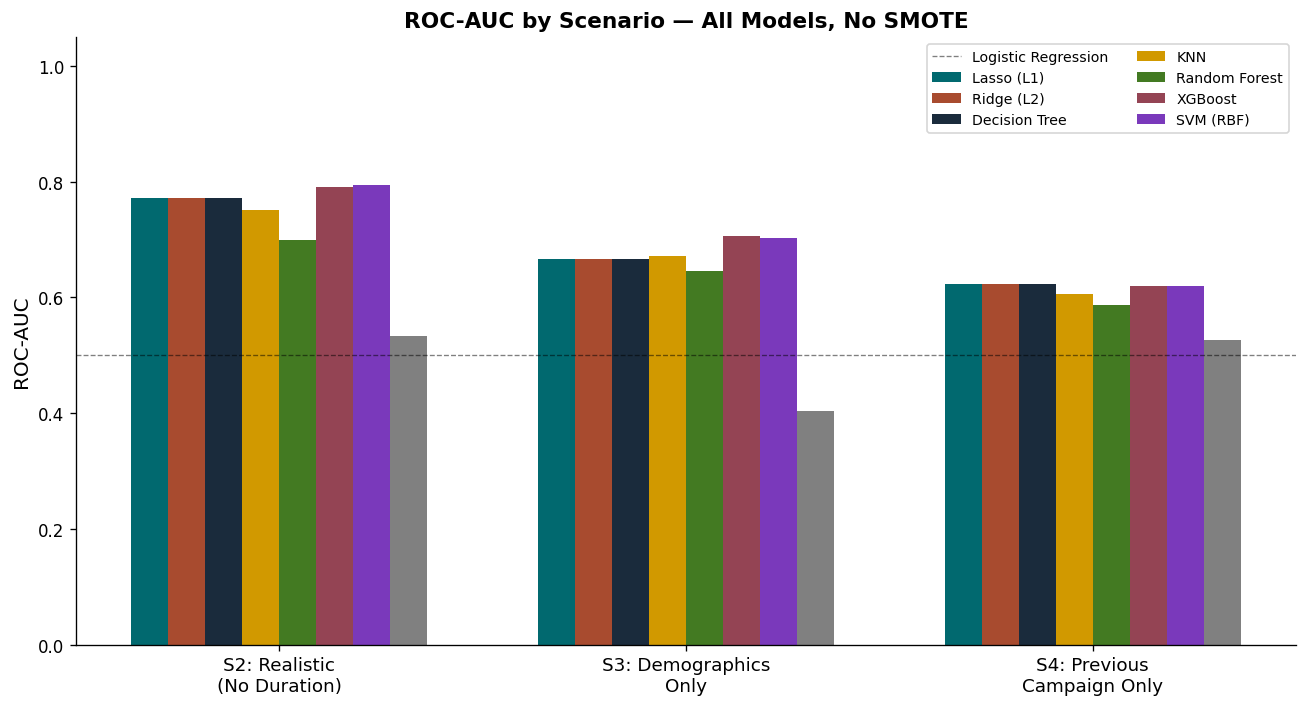

Saved: eval_scenario_auc_bar.png


In [16]:
# ============================================================
# 10B. ROC-AUC BY SCENARIO — GROUPED BAR CHART
#      Scenarios: S2, S3, S4 (excluding S1 — data leakage)
#      One bar per model, grouped by scenario
# ============================================================

SCENARIOS_BAR = [
    ('S2_Realistic_NoDuration', 'S2: Realistic\n(No Duration)'),
    ('S3_DemographicsOnly',     'S3: Demographics\nOnly'),
    ('S4_PreviousOnly',         'S4: Previous\nCampaign Only'),
]

MODELS_ORDER_BAR = ['Logistic Regression', 'Lasso (L1)', 'Ridge (L2)', 'Decision Tree',
                     'KNN', 'Random Forest', 'XGBoost', 'SVM (RBF)']

MODEL_COLORS_BAR = [TEAL, RUST, NAVY, GOLD,
                    '#437A22', '#944454', PURPLE, 'grey']

fig, ax = plt.subplots(figsize=(11, 6))

n_scen_b   = len(SCENARIOS_BAR)
n_models_b = len(MODELS_ORDER_BAR)
bar_w_b    = 0.10
group_gap_b = 0.3

x_positions_b = []
x_labels_b    = []

for s_idx, (scen_key, scen_label) in enumerate(SCENARIOS_BAR):
    group_center = s_idx * (n_models_b * bar_w_b + group_gap_b)
    for m_idx, (model_name, color) in enumerate(zip(MODELS_ORDER_BAR, MODEL_COLORS_BAR)):
        x = group_center + m_idx * bar_w_b
        row = all_results_df[
            (all_results_df['Model'] == model_name) &
            (all_results_df['Scenario'] == scen_key) &
            (all_results_df['SMOTE'] == 'No')
        ]
        auc_val = row['ROC-AUC'].values[0] if len(row) else 0.0
        ax.bar(x, auc_val, width=bar_w_b, color=color,
               label=model_name if s_idx == 0 else '_nolegend_')
    x_labels_b.append(scen_label)
    x_positions_b.append(group_center + (n_models_b - 1) * bar_w_b / 2)

ax.set_xticks(x_positions_b)
ax.set_xticklabels(x_labels_b, fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('ROC-AUC by Scenario — All Models, No SMOTE', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='k', linestyle='--', lw=0.8, alpha=0.5)
ax.legend(MODELS_ORDER_BAR, loc='upper right', fontsize=8.5, ncol=2)
plt.tight_layout()
plt.savefig('eval_scenario_auc_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_scenario_auc_bar.png")


## 10C. Duration Inflation — S1 vs S2 AUC, All Models

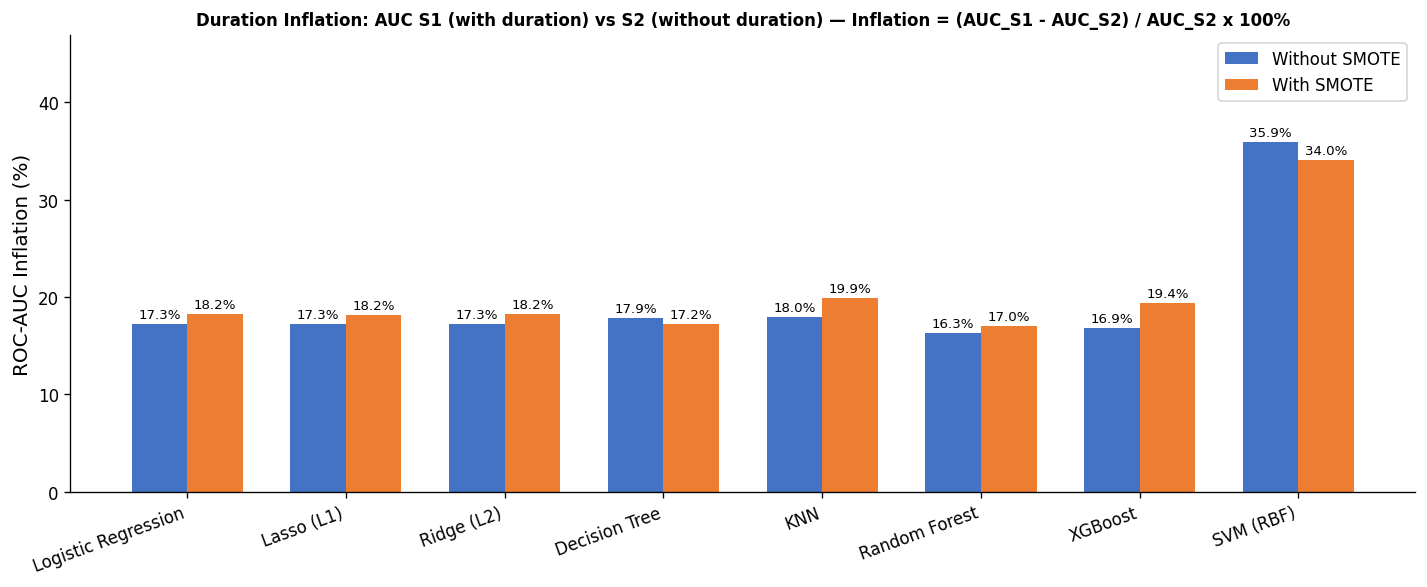

Saved: eval_duration_inflation.png


In [17]:
# ============================================================
# 10C. DURATION INFLATION BAR CHART
#      Inflation = (AUC_S1 - AUC_S2) / AUC_S2 * 100%
#      Two bars per model: No SMOTE (blue) | With SMOTE (orange)
# ============================================================

MODELS_ORDER_DI = ['Logistic Regression', 'Lasso (L1)', 'Ridge (L2)', 'Decision Tree',
                    'KNN', 'Random Forest', 'XGBoost', 'SVM (RBF)']

def get_auc_di(model, scenario, smote):
    row = all_results_df[
        (all_results_df['Model'] == model) &
        (all_results_df['Scenario'] == scenario) &
        (all_results_df['SMOTE'] == smote)
    ]
    return row['ROC-AUC'].values[0] if len(row) else np.nan

no_smote_infl  = []
with_smote_infl = []
for m in MODELS_ORDER_DI:
    s1_no  = get_auc_di(m, 'S1_All_WithDuration',    'No')
    s2_no  = get_auc_di(m, 'S2_Realistic_NoDuration', 'No')
    s1_yes = get_auc_di(m, 'S1_All_WithDuration',    'Yes')
    s2_yes = get_auc_di(m, 'S2_Realistic_NoDuration', 'Yes')
    no_smote_infl.append( (s1_no  - s2_no)  / s2_no  * 100 if (s2_no  and not np.isnan(s2_no))  else np.nan)
    with_smote_infl.append((s1_yes - s2_yes) / s2_yes * 100 if (s2_yes and not np.isnan(s2_yes)) else np.nan)

fig, ax = plt.subplots(figsize=(12, 5))
x_di = np.arange(len(MODELS_ORDER_DI))
w_di = 0.35

bars1 = ax.bar(x_di - w_di/2, no_smote_infl,  width=w_di, color='#4472C4', label='Without SMOTE')
bars2 = ax.bar(x_di + w_di/2, with_smote_infl, width=w_di, color='#ED7D31', label='With SMOTE')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_di)
ax.set_xticklabels(MODELS_ORDER_DI, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('ROC-AUC Inflation (%)', fontsize=12)
ax.set_title('Duration Inflation: AUC S1 (with duration) vs S2 (without duration) — Inflation = (AUC_S1 - AUC_S2) / AUC_S2 x 100%',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=10)
valid_vals = [v for v in no_smote_infl + with_smote_infl if not np.isnan(v)]
ax.set_ylim(0, max(valid_vals) * 1.25 + 2)
ax.axhline(0, color='k', lw=0.6)
plt.tight_layout()
plt.savefig('eval_duration_inflation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_duration_inflation.png")


## 11. Feature Importance — S2 (Top 15)

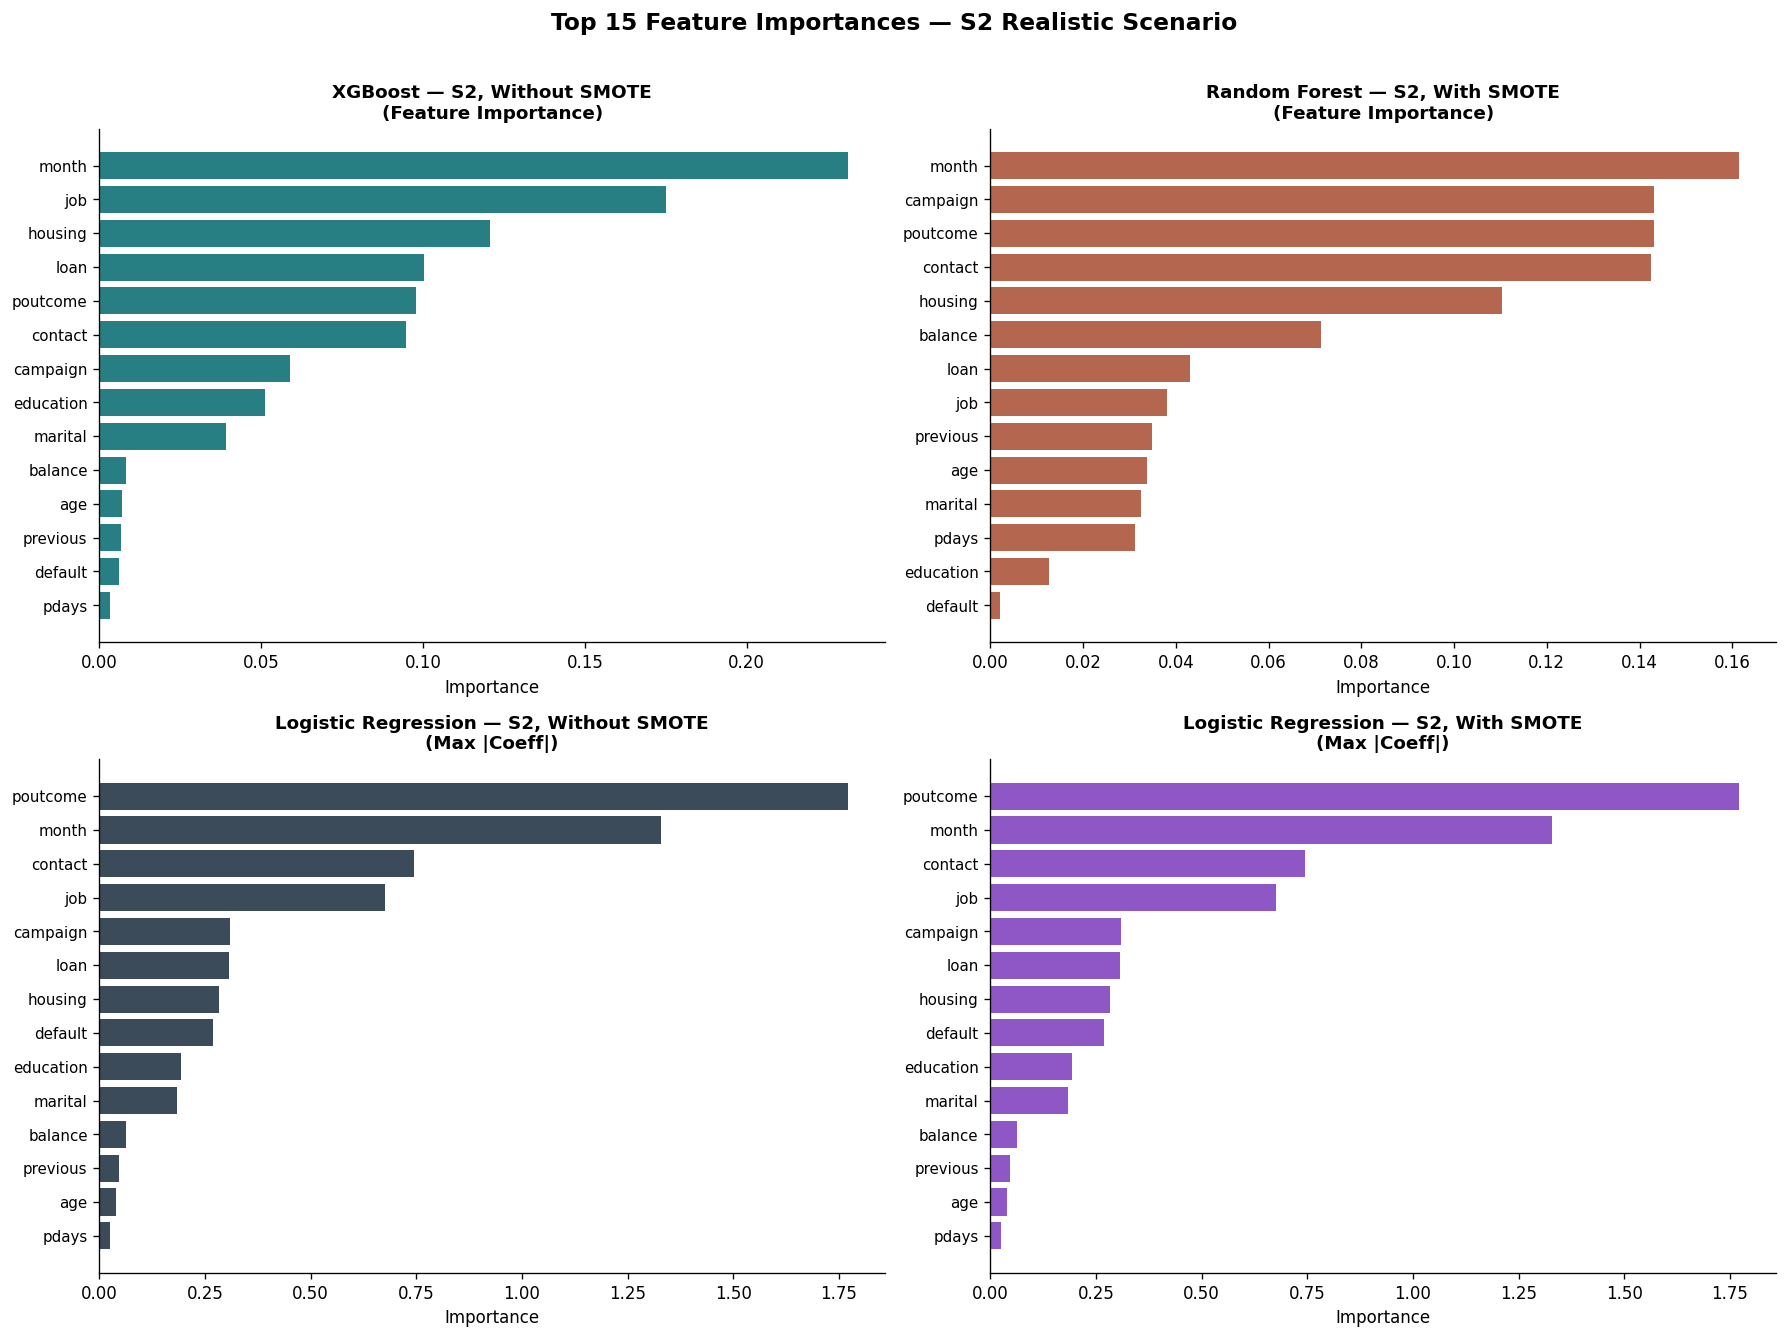

Saved: eval_feature_importance.png


In [18]:
# ============================================================
# 11. FEATURE IMPORTANCE — S2, Top 15
#     XGBoost (no SMOTE), Random Forest (with SMOTE)
#     LR: max |coefficient| across OHE dummies,
#         then OHE dummies for same base feature → consolidated
# ============================================================

def get_feature_names(pipeline, X_train):
    """Extract feature names after ColumnTransformer."""
    prep = pipeline.named_steps['preprocessor']
    num_names = prep.transformers_[0][2]
    ohe       = prep.transformers_[1][1]
    cat_names = ohe.get_feature_names_out(
        prep.transformers_[1][2]).tolist()
    return num_names + cat_names


def consolidate_month_ohe(series):
    """
    For tree models: group OHE dummies back to original feature.
    month_xxx → 'month' (sum).
    For LR: max |coef| approach is applied separately.
    """
    out = {}
    for feat, val in series.items():
        base = feat.split('_')[0] if '_' in feat else feat
        # Known categorical bases
        cat_bases = ['job','marital','education','default',
                     'housing','loan','contact','month','poutcome']
        matched = next((b for b in cat_bases if feat.startswith(b+'_')), None)
        if matched:
            out[matched] = out.get(matched, 0) + abs(val)
        else:
            out[feat] = abs(val)
    return pd.Series(out).sort_values(ascending=False)


def get_importance_tree(pipeline, X_train, model_step='classifier'):
    clf       = pipeline.named_steps[model_step]
    feat_names = get_feature_names(pipeline, X_train)
    imp        = pd.Series(clf.feature_importances_, index=feat_names)
    return consolidate_month_ohe(imp)


def get_importance_lr_max(pipeline, X_train, model_step='classifier'):
    """
    LR feature importance: max |coefficient| across OHE dummies.
    Avoids inflating high-cardinality features (e.g., month with 12 dummies).
    """
    clf        = pipeline.named_steps[model_step]
    feat_names = get_feature_names(pipeline, X_train)
    coef       = pd.Series(np.abs(clf.coef_[0]), index=feat_names)
    # Group: take max |coef| per original feature
    out = {}
    cat_bases = ['job','marital','education','default',
                 'housing','loan','contact','month','poutcome']
    for feat, val in coef.items():
        matched = next((b for b in cat_bases if feat.startswith(b+'_')), None)
        base    = matched if matched else feat
        out[base] = max(out.get(base, 0), val)
    return pd.Series(out).sort_values(ascending=False)


# ── XGBoost S2 No SMOTE ───────────────────────────────────────────
key_xgb = ('XGBoost', 'S2_Realistic_NoDuration', False)
imp_xgb = get_importance_tree(advanced_pipelines[key_xgb], X_train_S2)

# ── Random Forest S2 With SMOTE ───────────────────────────────────
key_rf  = ('Random Forest', 'S2_Realistic_NoDuration', True)
imp_rf  = get_importance_tree(advanced_pipelines[key_rf], X_train_S2, 'classifier')

# ── LR S2 No SMOTE ────────────────────────────────────────────────
key_lr  = ('Logistic Regression', 'S2_Realistic_NoDuration', False)
imp_lr  = get_importance_lr_max(baseline_pipelines[key_lr], X_train_S2)

# ── LR S2 With SMOTE ─────────────────────────────────────────────
key_lr_s = ('Logistic Regression', 'S2_Realistic_NoDuration', True)
imp_lr_s  = get_importance_lr_max(baseline_pipelines[key_lr_s], X_train_S2)

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

configs = [
    (imp_xgb, 'XGBoost — S2, Without SMOTE\n(Feature Importance)',       TEAL,   axes[0,0]),
    (imp_rf,  'Random Forest — S2, With SMOTE\n(Feature Importance)',     RUST,   axes[0,1]),
    (imp_lr,  'Logistic Regression — S2, Without SMOTE\n(Max |Coeff|)',   NAVY,   axes[1,0]),
    (imp_lr_s,'Logistic Regression — S2, With SMOTE\n(Max |Coeff|)',      PURPLE, axes[1,1]),
]

for imp, title, color, ax in configs:
    top = imp.head(TOP_N)
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Top 15 Feature Importances — S2 Realistic Scenario',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eval_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_feature_importance.png")


## 12. Threshold Optimisation
Focus: **S2 (Realistic), XGBoost without SMOTE** — best deployment candidate.

The default threshold of 0.50 is designed for balanced data. With only 11.7% positives, it misses most subscribers. We find the optimal threshold by maximising F1 score on the PR curve.


In [19]:
# ============================================================
# 12. THRESHOLD OPTIMISATION — XGBoost S2 (No SMOTE)
# ============================================================

key  = ('XGBoost', 'S2_Realistic_NoDuration', False)
pipe = advanced_pipelines[key]
y_proba_xgb_s2 = advanced_probas[key]

# ── Precision-Recall curve ────────────────────────────────────────
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_proba_xgb_s2)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)

# Optimal threshold = max F1
opt_idx   = f1_arr.argmax()
opt_thresh = thresh_arr[opt_idx]
opt_prec   = prec_arr[opt_idx]
opt_rec    = rec_arr[opt_idx]
opt_f1     = f1_arr[opt_idx]

# Default & Aggressive thresholds
def metrics_at_thresh(y_true, y_proba, thresh):
    y_pred = (y_proba >= thresh).astype(int)
    return {
        'Threshold':        round(thresh, 4),
        'Precision':        round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':           round(recall_score(y_true, y_pred),    4),
        'F1':               round(f1_score(y_true, y_pred),        4),
        'Subscribers Caught': int(recall_score(y_true, y_pred) * y_true.sum()),
        'Total Called':       int(y_pred.sum()),
    }

AGG_THRESH = 0.13
thresh_comparison = pd.DataFrame([
    {**{'Setting': 'Default (0.50)'},  **metrics_at_thresh(y_test, y_proba_xgb_s2, 0.50)},
    {**{'Setting': f'Optimal ({opt_thresh:.3f})'},  **metrics_at_thresh(y_test, y_proba_xgb_s2, opt_thresh)},
    {**{'Setting': f'Aggressive ({AGG_THRESH})'},   **metrics_at_thresh(y_test, y_proba_xgb_s2, AGG_THRESH)},
])

print("THRESHOLD COMPARISON — XGBoost S2 (No SMOTE)")
print(f"Optimal threshold found at: {opt_thresh:.4f} (max F1={opt_f1:.4f})")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb_s2):.4f}\n")
display(thresh_comparison.style
    .set_caption('XGBoost S2 — Threshold Optimisation Results')
    .format({c: '{:.4f}' for c in ['Precision','Recall','F1']})
    .apply(lambda x: ['background-color: #d4edda' if x.name==1 else '' for _ in x], axis=1))


THRESHOLD COMPARISON — XGBoost S2 (No SMOTE)
Optimal threshold found at: 0.1955 (max F1=0.4855)
ROC-AUC: 0.7940



,Setting,Threshold,Precision,Recall,F1,Subscribers Caught,Total Called
0,Default (0.50),0.500000,0.6694,0.2278,0.3399,241,360
1,Optimal (0.196),0.195500,0.4584,0.5161,0.4855,546,1191
2,Aggressive (0.13),0.130000,0.3521,0.6040,0.4448,639,1815


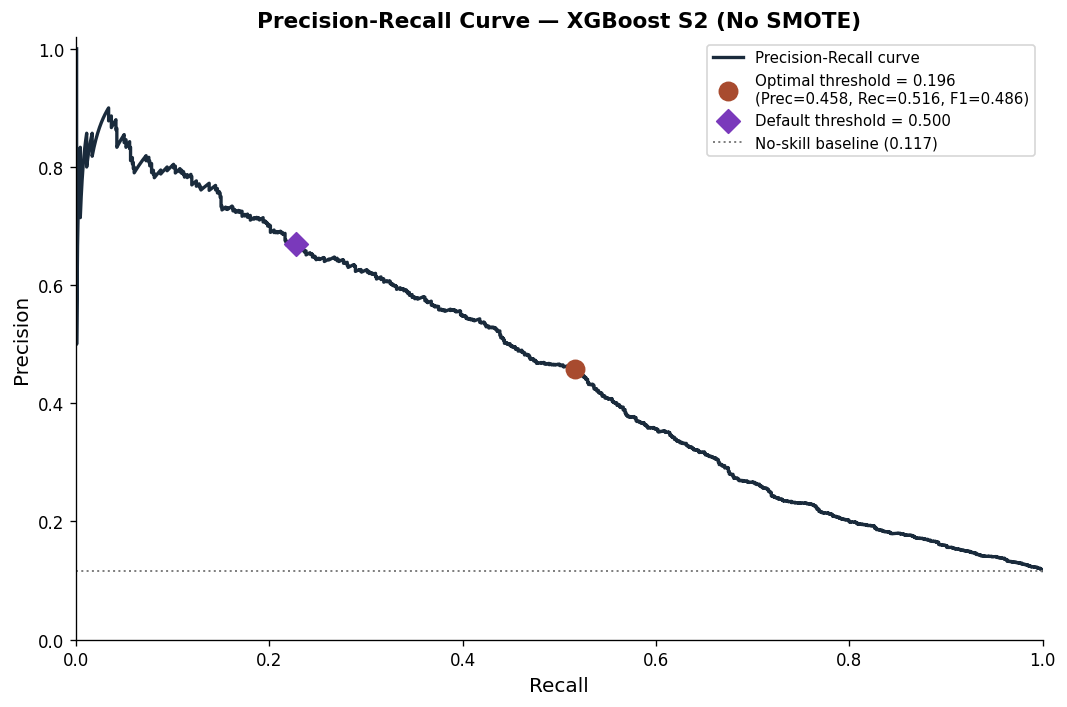

Saved: eval_pr_curve_xgb_s2.png


In [20]:
# ── Precision-Recall Curve plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(rec_arr[:-1], prec_arr[:-1], color=NAVY, lw=2,
        label='Precision-Recall curve')
ax.scatter([opt_rec], [opt_prec], color=RUST, s=120, zorder=5,
           label=f'Optimal threshold = {opt_thresh:.3f}\n(Prec={opt_prec:.3f}, Rec={opt_rec:.3f}, F1={opt_f1:.3f})')
ax.scatter([metrics_at_thresh(y_test, y_proba_xgb_s2, 0.50)['Recall']],
           [metrics_at_thresh(y_test, y_proba_xgb_s2, 0.50)['Precision']],
           color=PURPLE, marker='D', s=100, zorder=5,
           label=f'Default threshold = 0.500')
ax.axhline(y_test.mean(), color='grey', linestyle=':', lw=1.2,
           label=f'No-skill baseline ({y_test.mean():.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — XGBoost S2 (No SMOTE)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('eval_pr_curve_xgb_s2.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_pr_curve_xgb_s2.png")


In [21]:
# ── Threshold optimisation: ALL S2 models (no SMOTE) ─────────────

print("=" * 80)
print("THRESHOLD OPTIMISATION SUMMARY — All S2 Models (No SMOTE)")
print("=" * 80)

thresh_summary = []

# Baseline S2 no SMOTE
for mname in BASELINE_MODEL_NAMES:
    key = (mname, 'S2_Realistic_NoDuration', False)
    if key in baseline_probas:
        proba_arr = baseline_probas[key]
        p_arr, r_arr, t_arr = precision_recall_curve(y_test, proba_arr)
        f1_tmp = 2*p_arr[:-1]*r_arr[:-1]/(p_arr[:-1]+r_arr[:-1]+1e-9)
        oi = f1_tmp.argmax()
        thresh_summary.append({
            'Model': mname, 'Type': 'Baseline',
            'Optimal Threshold': round(t_arr[oi], 4),
            'Precision (opt)':   round(p_arr[oi], 4),
            'Recall (opt)':      round(r_arr[oi], 4),
            'F1 (opt)':          round(f1_tmp[oi], 4),
            'F1 (default 0.5)':  round(f1_score(y_test, (proba_arr>=0.5).astype(int)), 4),
            'ROC-AUC':           round(roc_auc_score(y_test, proba_arr), 4),
        })

# Advanced S2 no SMOTE (non-SVM)
for mname in ['KNN', 'Random Forest', 'XGBoost']:
    key = (mname, 'S2_Realistic_NoDuration', False)
    if key in advanced_probas:
        proba_arr = advanced_probas[key]
        p_arr, r_arr, t_arr = precision_recall_curve(y_test, proba_arr)
        f1_tmp = 2*p_arr[:-1]*r_arr[:-1]/(p_arr[:-1]+r_arr[:-1]+1e-9)
        oi = f1_tmp.argmax()
        thresh_summary.append({
            'Model': mname, 'Type': 'Advanced',
            'Optimal Threshold': round(t_arr[oi], 4),
            'Precision (opt)':   round(p_arr[oi], 4),
            'Recall (opt)':      round(r_arr[oi], 4),
            'F1 (opt)':          round(f1_tmp[oi], 4),
            'F1 (default 0.5)':  round(f1_score(y_test, (proba_arr>=0.5).astype(int)), 4),
            'ROC-AUC':           round(roc_auc_score(y_test, proba_arr), 4),
        })

thresh_summary_df = pd.DataFrame(thresh_summary).sort_values('ROC-AUC', ascending=False)
display(thresh_summary_df.style
    .background_gradient(subset=['ROC-AUC','F1 (opt)'], cmap='YlOrBr')
    .format({c: '{:.4f}' for c in ['Optimal Threshold','Precision (opt)',
                                    'Recall (opt)','F1 (opt)',
                                    'F1 (default 0.5)','ROC-AUC']})
    .set_caption('Threshold Optimisation — S2 All Models (No SMOTE)'))


THRESHOLD OPTIMISATION SUMMARY — All S2 Models (No SMOTE)


,Model,Type,Optimal Threshold,Precision (opt),Recall (opt),F1 (opt),F1 (default 0.5),ROC-AUC
6,XGBoost,Advanced,0.1955,0.4584,0.5161,0.4855,0.3399,0.7940
5,Random Forest,Advanced,0.2137,0.4690,0.5000,0.4840,0.2657,0.7911
0,Logistic Regression,Baseline,0.2059,0.4771,0.4329,0.4539,0.2836,0.7724
2,Ridge (L2),Baseline,0.2059,0.4771,0.4329,0.4539,0.2836,0.7724
1,Lasso (L1),Baseline,0.2071,0.4796,0.4329,0.4550,0.2851,0.7724
3,Decision Tree,Baseline,0.2500,0.5146,0.3828,0.4390,0.3170,0.7518
4,KNN,Advanced,0.4000,0.3852,0.3885,0.3868,0.3039,0.7000


## 13. Lift & Cumulative Gain Analysis
**Business question:** If the bank can only contact 20% of customers, how many more subscribers does the model find vs. random dialling?


In [22]:
# ============================================================
# 13. LIFT ANALYSIS — XGBoost S2 (No SMOTE) + All S2 models
# ============================================================

def compute_lift_curve(y_true, y_proba):
    """Returns (pct_called, lift, cum_gain_pct) arrays."""
    order    = np.argsort(y_proba)[::-1]
    y_sorted = np.array(y_true)[order]
    total    = len(y_true)
    pos_total = y_true.sum()

    cum_pos    = np.cumsum(y_sorted)
    pct_called = np.arange(1, total+1) / total * 100
    cum_gain   = cum_pos / pos_total * 100
    baseline   = pct_called / 100 * pos_total
    lift       = cum_pos / (baseline + 1e-9)

    return pct_called, lift, cum_gain


pct_xgb, lift_xgb, gain_xgb = compute_lift_curve(
    y_test.values, y_proba_xgb_s2
)

# ── Lift at 20% ───────────────────────────────────────────────────
idx_20 = np.searchsorted(pct_xgb, 20)
lift_at_20      = lift_xgb[idx_20]
gain_at_20      = gain_xgb[idx_20]
subscribers_20  = int(gain_at_20 / 100 * y_test.sum())
random_20       = int(0.20 * y_test.sum())
n_called_20     = int(0.20 * len(y_test))

print("=" * 60)
print("LIFT AT TOP 20% — XGBoost S2 (No SMOTE)")
print("=" * 60)
print(f"  Total test customers:     {len(y_test):,}")
print(f"  Total subscribers (test): {y_test.sum():,}")
print(f"  Customers called (top 20%): {n_called_20:,}")
print(f"  Subscribers found (model):  {subscribers_20:,}")
print(f"  Subscribers found (random): {random_20:,}")
print(f"  Lift at 20%:                {lift_at_20:.2f}x")
print(f"  Cumulative gain at 20%:     {gain_at_20:.1f}%")
print(f"  Extra subscribers vs random: +{subscribers_20 - random_20:,}")


LIFT AT TOP 20% — XGBoost S2 (No SMOTE)
  Total test customers:     9,043
  Total subscribers (test): 1,058
  Customers called (top 20%): 1,808
  Subscribers found (model):  637
  Subscribers found (random): 211
  Lift at 20%:                3.01x
  Cumulative gain at 20%:     60.2%
  Extra subscribers vs random: +426


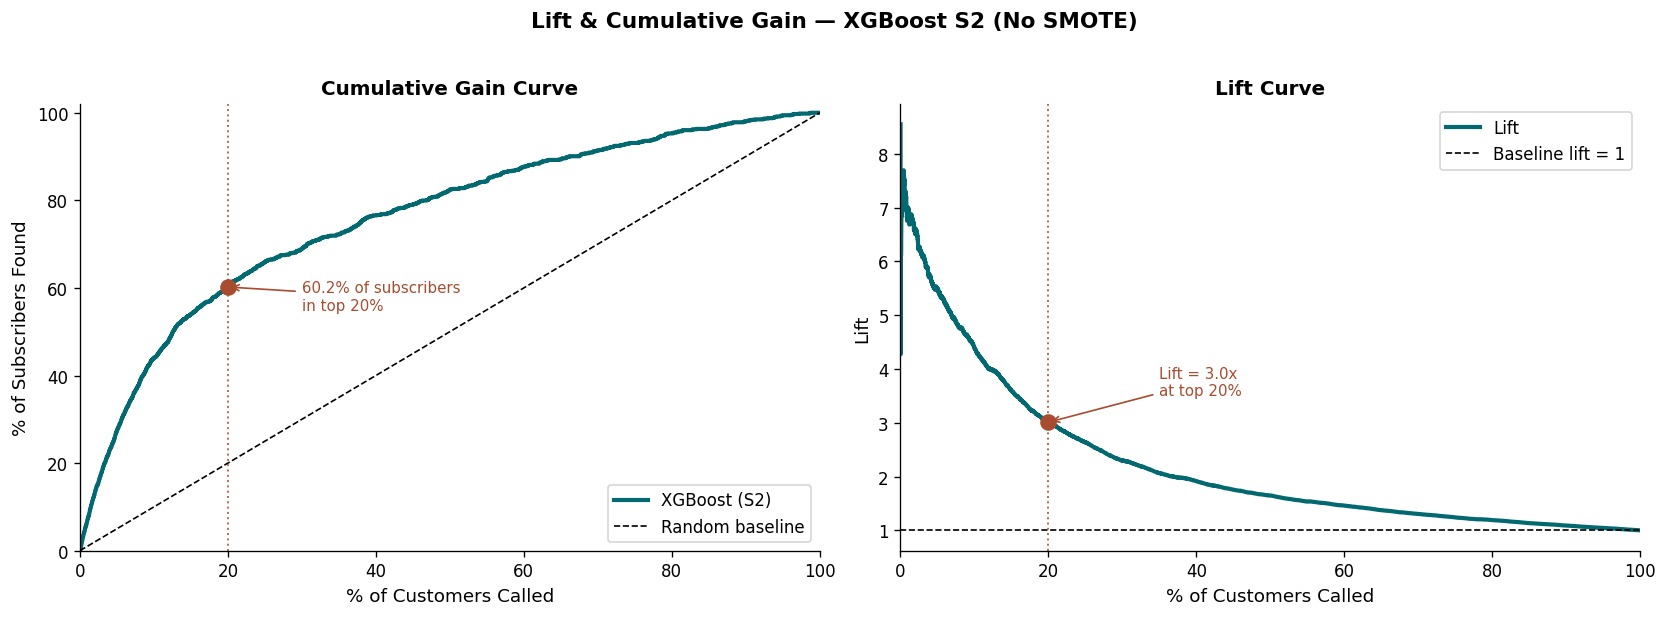

Saved: eval_lift_chart.png


In [23]:
# ── Cumulative Gain + Lift chart ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Cumulative Gain ---
ax1.plot(pct_xgb, gain_xgb, color=TEAL, lw=2.5, label='XGBoost (S2)')
ax1.plot([0, 100], [0, 100], 'k--', lw=1, label='Random baseline')
ax1.axvline(20, color=RUST, lw=1.2, linestyle=':', alpha=0.8)
ax1.scatter([pct_xgb[idx_20]], [gain_xgb[idx_20]],
            color=RUST, s=80, zorder=5)
ax1.annotate(f'{gain_at_20:.1f}% of subscribers\nin top 20%',
             xy=(pct_xgb[idx_20], gain_xgb[idx_20]),
             xytext=(30, 55), fontsize=9, color=RUST,
             arrowprops=dict(arrowstyle='->', color=RUST))
ax1.set_xlabel('% of Customers Called', fontsize=11)
ax1.set_ylabel('% of Subscribers Found', fontsize=11)
ax1.set_title('Cumulative Gain Curve', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10); ax1.set_xlim([0,100]); ax1.set_ylim([0,102])

# --- Lift Curve ---
ax2.plot(pct_xgb, lift_xgb, color=TEAL, lw=2.5, label='Lift')
ax2.axhline(1, color='k', lw=1, linestyle='--', label='Baseline lift = 1')
ax2.axvline(20, color=RUST, lw=1.2, linestyle=':', alpha=0.8)
ax2.scatter([pct_xgb[idx_20]], [lift_at_20],
            color=RUST, s=80, zorder=5)
ax2.annotate(f'Lift = {lift_at_20:.1f}x\nat top 20%',
             xy=(pct_xgb[idx_20], lift_at_20),
             xytext=(35, lift_at_20+0.5), fontsize=9, color=RUST,
             arrowprops=dict(arrowstyle='->', color=RUST))
ax2.set_xlabel('% of Customers Called', fontsize=11)
ax2.set_ylabel('Lift', fontsize=11)
ax2.set_title('Lift Curve', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10); ax2.set_xlim([0,100])

plt.suptitle('Lift & Cumulative Gain — XGBoost S2 (No SMOTE)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_lift_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_lift_chart.png")


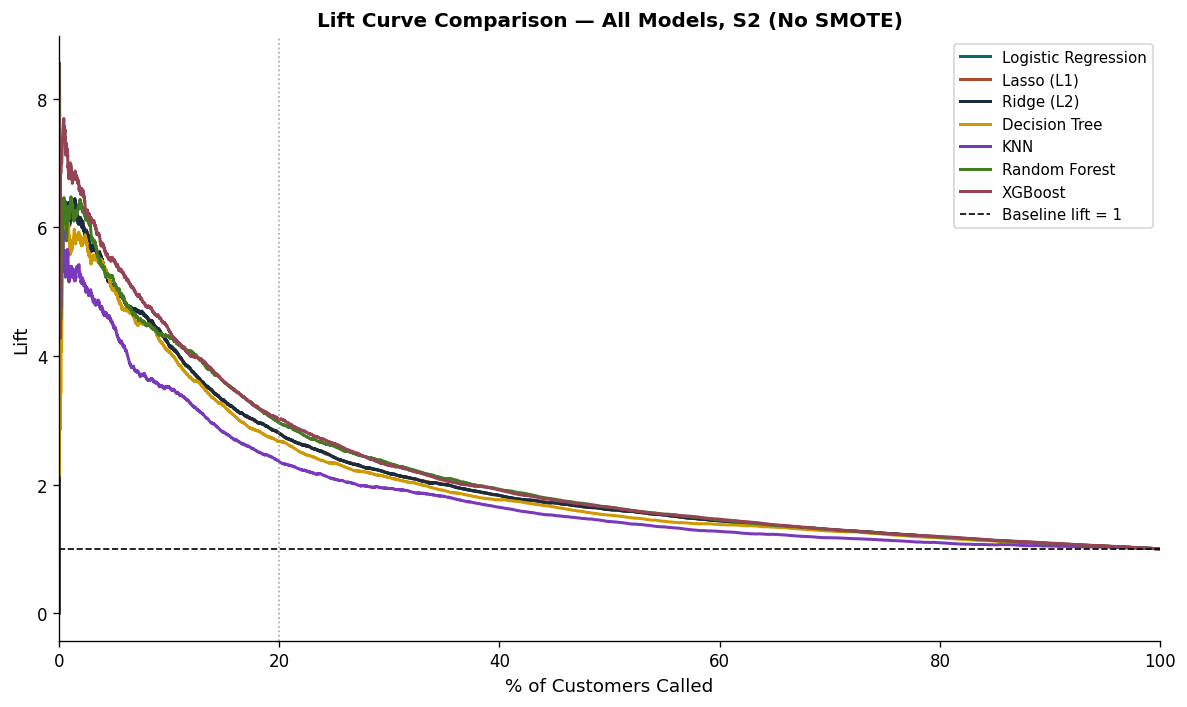

Saved: eval_lift_comparison.png


In [24]:
# ── Lift comparison: all retrained S2 models (no SMOTE) ───────────
fig, ax = plt.subplots(figsize=(10, 6))

all_proba_s2 = {
    **{m: baseline_probas[(m, 'S2_Realistic_NoDuration', False)]
       for m in BASELINE_MODEL_NAMES if (m, 'S2_Realistic_NoDuration', False) in baseline_probas},
    **{m: advanced_probas[(m, 'S2_Realistic_NoDuration', False)]
       for m in NON_SVM_NAMES
       if (m, 'S2_Realistic_NoDuration', False) in advanced_probas}
}

for i, (mname, proba) in enumerate(all_proba_s2.items()):
    pct, lft, _ = compute_lift_curve(y_test.values, proba)
    ax.plot(pct, lft, color=COLORS[i % len(COLORS)], lw=1.8, label=mname)

ax.axhline(1, color='k', lw=1, linestyle='--', label='Baseline lift = 1')
ax.axvline(20, color='grey', lw=1, linestyle=':', alpha=0.7)
ax.set_xlabel('% of Customers Called', fontsize=11)
ax.set_ylabel('Lift', fontsize=11)
ax.set_title('Lift Curve Comparison — All Models, S2 (No SMOTE)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 100])
plt.tight_layout()
plt.savefig('eval_lift_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eval_lift_comparison.png")


## 14. Summary & Recommendations

In [25]:
# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("=" * 80)
print("FINAL MODEL RANKING — S2 Realistic Scenario (No SMOTE), by ROC-AUC")
print("=" * 80)

s2_no_smote = all_results_df[
    (all_results_df['Scenario'] == 'S2_Realistic_NoDuration') &
    (all_results_df['SMOTE'] == 'No')
][['Model','Accuracy','Precision','Recall','F1','ROC-AUC']].sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
s2_no_smote.insert(0, 'Rank', s2_no_smote.index + 1)

display(s2_no_smote[['Rank','Model','Accuracy','Precision','Recall','F1','ROC-AUC']].style
    .background_gradient(subset=['ROC-AUC','F1'], cmap='YlOrBr')
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','F1','ROC-AUC']})
    .set_caption("S2 Realistic — All Models (No SMOTE), Ranked by ROC-AUC"))

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
best_overall = all_results_df.iloc[0]
print(f"  Best model overall:     {best_overall['Model']} | {best_overall['Scenario']} | SMOTE={best_overall['SMOTE']}")
print(f"    ROC-AUC = {best_overall['ROC-AUC']:.4f}  |  F1 = {best_overall['F1']:.4f}  |  Recall = {best_overall['Recall']:.4f}")

print(f"\n  Best realistic model:   XGBoost | S2 (No SMOTE)")
print(f"    ROC-AUC = 0.7940  |  Optimal threshold = {opt_thresh:.3f}")
print(f"    At optimal threshold: Precision={opt_prec:.3f}, Recall={opt_rec:.3f}, F1={opt_f1:.3f}")
print(f"    Subscribers caught (top 20%): {subscribers_20:,} vs {random_20:,} random — Lift = {lift_at_20:.1f}x")

print("\n  SMOTE effect:  Increases Recall at cost of Precision.")
print("  Recommendation: Deploy XGBoost (S2) with threshold=0.196 for balanced campaign ROI.")
print("\n" + "=" * 80)
print("MEMBER 4 — EVALUATION COMPLETE")
print("=" * 80)


FINAL MODEL RANKING — S2 Realistic Scenario (No SMOTE), by ROC-AUC


,Rank,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,XGBoost,0.8965,0.6694,0.2278,0.3399,0.7940
1,2,Random Forest,0.8943,0.7090,0.1635,0.2657,0.7911
2,3,Logistic Regression,0.8933,0.6609,0.1805,0.2836,0.7724
3,4,Ridge (L2),0.8933,0.6609,0.1805,0.2836,0.7724
4,5,Lasso (L1),0.8935,0.6644,0.1815,0.2851,0.7724
5,6,Decision Tree,0.8935,0.6393,0.2060,0.3117,0.7518
6,7,KNN,0.8865,0.5385,0.2117,0.3039,0.7000
7,8,SVM (RBF),0.6195,0.1280,0.3875,0.1924,0.5330



KEY FINDINGS
  Best model overall:     XGBoost | S1_All_WithDuration | SMOTE=No
    ROC-AUC = 0.9279  |  F1 = 0.5438  |  Recall = 0.4603

  Best realistic model:   XGBoost | S2 (No SMOTE)
    ROC-AUC = 0.7940  |  Optimal threshold = 0.196
    At optimal threshold: Precision=0.458, Recall=0.516, F1=0.486
    Subscribers caught (top 20%): 637 vs 211 random — Lift = 3.0x

  SMOTE effect:  Increases Recall at cost of Precision.
  Recommendation: Deploy XGBoost (S2) with threshold=0.196 for balanced campaign ROI.

MEMBER 4 — EVALUATION COMPLETE
